<a href="https://colab.research.google.com/github/PandeyChhaya/6CS012-AI-ML/blob/main/Worksheet%204.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uploading the zip file to colab


In [ ]:
from google.colab import files
upload= files.upload()

Saving Copy of devnagari digit (1).zip to Copy of devnagari digit (1).zip


Unzipping and checking the structure


In [ ]:
import zipfile, os

with zipfile.ZipFile("Copy of devnagari digit (1).zip", "r") as z:
    z.extractall("devanagari")

for root, dirs, files in os.walk("devanagari"):
    level = root.replace("devanagari", "").count(os.sep)
    print(" " * 2 * level + os.path.basename(root) + "/")
    if level == 2:
        print(" " * 2 * (level+1) + f"({len(files)} images)")

devanagari/
  DevanagariHandwrittenDigitDataset/
    Test/
      (0 images)
      digit_6/
      digit_3/
      digit_2/
      digit_8/
      digit_5/
      digit_9/
      digit_0/
      digit_7/
      digit_1/
      digit_4/
    Train/
      (0 images)
      digit_6/
      digit_3/
      digit_2/
      digit_8/
      digit_5/
      digit_9/
      digit_0/
      digit_7/
      digit_1/
      digit_4/


Task 1: Loading and Preprocessing the data


Training set:   (17000, 28, 28, 1), Labels: (17000, 10)
Testing set:    (3000, 28, 28, 1),  Labels: (3000, 10)


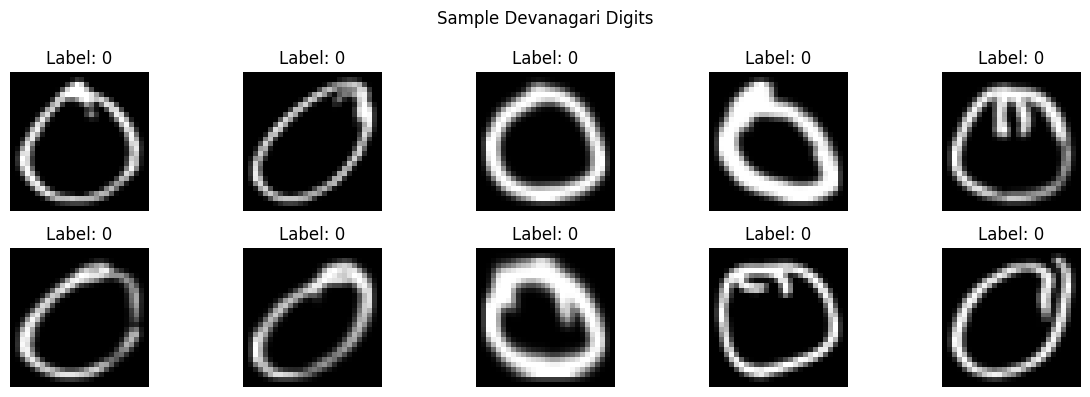

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

train_dir = "devanagari/DevanagariHandwrittenDigitDataset/Train"
test_dir  = "devanagari/DevanagariHandwrittenDigitDataset/Test"

img_height, img_width = 28, 28

def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img = np.array(img) / 255.0
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images), np.array(labels)

# Load data
x_train, y_train = load_images_from_folder(train_dir)
x_test,  y_test  = load_images_from_folder(test_dir)

# Reshape for Keras
x_train = x_train.reshape(-1, img_height, img_width, 1)
x_test  = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat  = to_categorical(y_test,  num_classes=10)

print(f"Training set:   {x_train.shape}, Labels: {y_train_cat.shape}")
print(f"Testing set:    {x_test.shape},  Labels: {y_test_cat.shape}")

# Visualize sample images
class_names = sorted(os.listdir(train_dir))
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train_cat[i])}")
    plt.axis("off")
plt.suptitle("Sample Devanagari Digits")
plt.tight_layout()
plt.show()

Task 2: Building the FCN model


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

model = Sequential([
    Flatten(input_shape=(img_height, img_width, 1)),
    Dense(64,  activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(256, activation='sigmoid'),
    Dense(10,  activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

Task 3: Compiling the model


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Task 4:Training the Model

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

callbacks = [
    ModelCheckpoint("best_model.h5", save_best_only=True, monitor='val_accuracy', verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

history = model.fit(
    x_train, y_train_cat,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2518 - loss: 2.0912
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4437 - loss: 1.7385 - val_accuracy: 0.0000e+00 - val_loss: 6.4598
Epoch 2/20
 98/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7885 - loss: 0.7342
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8243 - loss: 0.5694 - val_accuracy: 0.0000e+00 - val_loss: 7.5794
Epoch 3/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8987 - loss: 0.3361
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9131 - loss: 0.2983 - val_accuracy: 0.0000e+00 - val_loss: 8.1890
Epoch 4/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9390 - loss: 0.2167
Epoch 4: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9441 - loss: 0.1986 - val_accuracy: 0.0000e+00 - val_loss: 8.7459
Epoch 5/20
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - a

Task 5: Plotting Curves and Evaluating

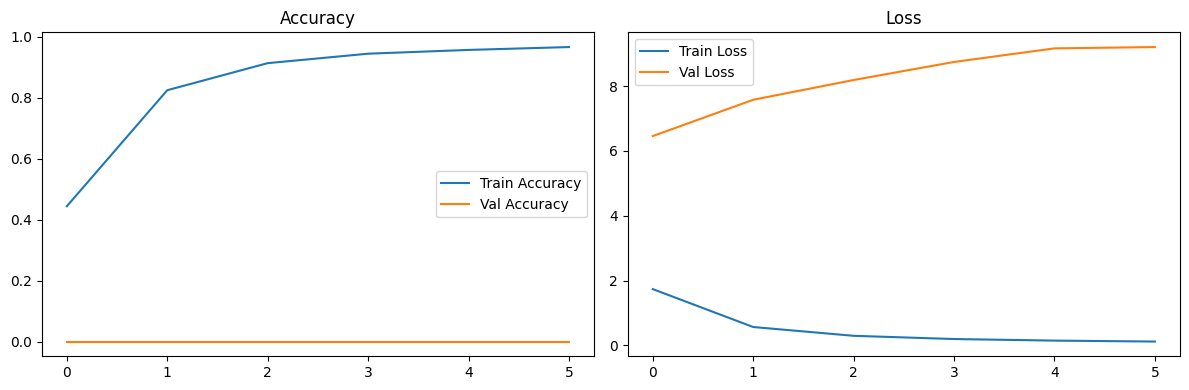

94/94 - 0s - 2ms/step - accuracy: 0.6180 - loss: 2.0475

Test Accuracy: 0.6180 | Test Loss: 2.0475


In [ ]:
# Plot accuracy and loss
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")

Task 6: Saving and Reloading the model

In [ ]:
model.save("devanagari_fcn_model.h5")
print("Model saved!")

from tensorflow.keras.models import load_model
loaded_model = load_model("devanagari_fcn_model.h5")

loss, acc = loaded_model.evaluate(x_test, y_test_cat, verbose=2)
print(f"Reloaded Model — Test Accuracy: {acc:.4f}")

Model saved!
94/94 - 1s - 7ms/step - accuracy: 0.6180 - loss: 2.0475
Reloaded Model — Test Accuracy: 0.6180


Task 7: Predicting


In [ ]:
predictions = loaded_model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test_cat, axis=1)

# Show first 5 predictions
for i in range(5):
    print(f"Predicted: {predicted_labels[i]} | Actual: {true_labels[i]}")

# Download the model
from google.colab import files
files.download("devanagari_fcn_model.h5")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: 7 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 7 | Actual: 0
Predicted: 0 | Actual: 0
Predicted: 0 | Actual: 0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>